# Taller SLAM Visual Simulado — Visual Odometry con ORB

**Dataset:** TUM RGB-D `freiburg1_xyz` (96 frames, ~3 segundos de secuencia)

**Pipeline:**
1. Cargar secuencia de imágenes
2. Detectar puntos clave con ORB
3. Emparejar descriptores entre frames consecutivos (BFMatcher)
4. Estimar movimiento con `findEssentialMat` + `recoverPose`
5. Acumular poses → trayectoria 2D estimada
6. Comparar contra ground truth del dataset

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob
from pathlib import Path

# Camera intrinsics — TUM freiburg1
FX, FY = 517.3, 516.5
CX, CY = 318.6, 255.3
K = np.array([[FX,  0, CX],
              [ 0, FY, CY],
              [ 0,  0,  1]], dtype=np.float64)

DATASET_DIR = Path('../dataset')
MEDIA_DIR   = Path('../media')

print('OpenCV:', cv2.__version__)

OpenCV: 4.13.0


## Paso 1 — Cargar secuencia de imágenes

Imágenes cargadas: 96
Resolución: 640x480


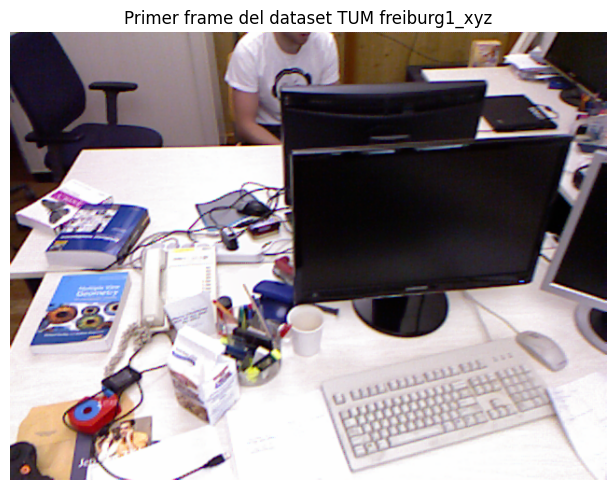

In [2]:
def load_images(dataset_dir):
    paths = sorted(glob.glob(str(dataset_dir / 'rgb' / '*.png')))
    images, timestamps = [], []
    for p in paths:
        img = cv2.imread(p)
        if img is not None:
            images.append(img)
            timestamps.append(float(Path(p).stem))
    return images, timestamps

images, timestamps = load_images(DATASET_DIR)
print(f'Imágenes cargadas: {len(images)}')
print(f'Resolución: {images[0].shape[1]}x{images[0].shape[0]}')

# Mostrar primer frame
plt.figure(figsize=(8, 5))
plt.imshow(cv2.cvtColor(images[0], cv2.COLOR_BGR2RGB))
plt.title('Primer frame del dataset TUM freiburg1_xyz')
plt.axis('off')
plt.tight_layout()
plt.show()

## Paso 2 — Detectar puntos clave con ORB

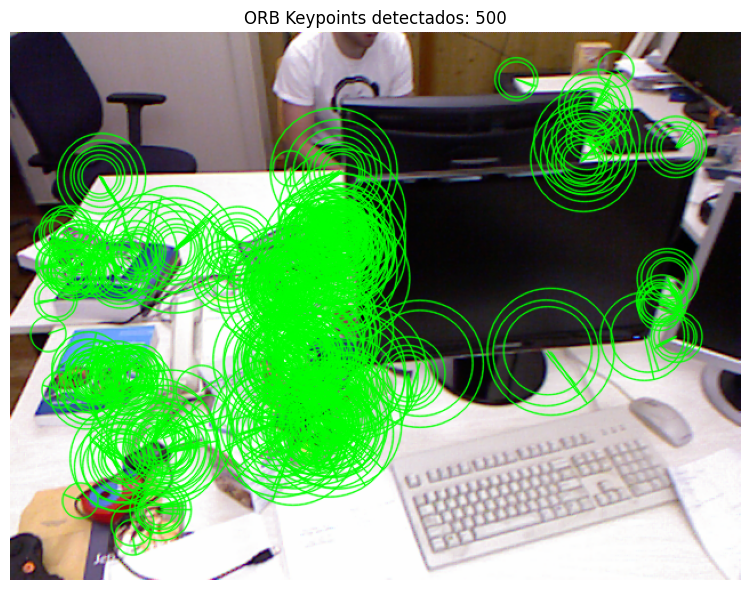

In [3]:
orb = cv2.ORB_create(nfeatures=500)

sample = images[0]
gray   = cv2.cvtColor(sample, cv2.COLOR_BGR2GRAY)
kp, _ = orb.detectAndCompute(gray, None)

vis = cv2.drawKeypoints(
    sample, kp, None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS,
    color=(0, 255, 0)
)

plt.figure(figsize=(9, 6))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.title(f'ORB Keypoints detectados: {len(kp)}')
plt.axis('off')
plt.tight_layout()
plt.show()

## Paso 3 — Emparejar características entre frames consecutivos

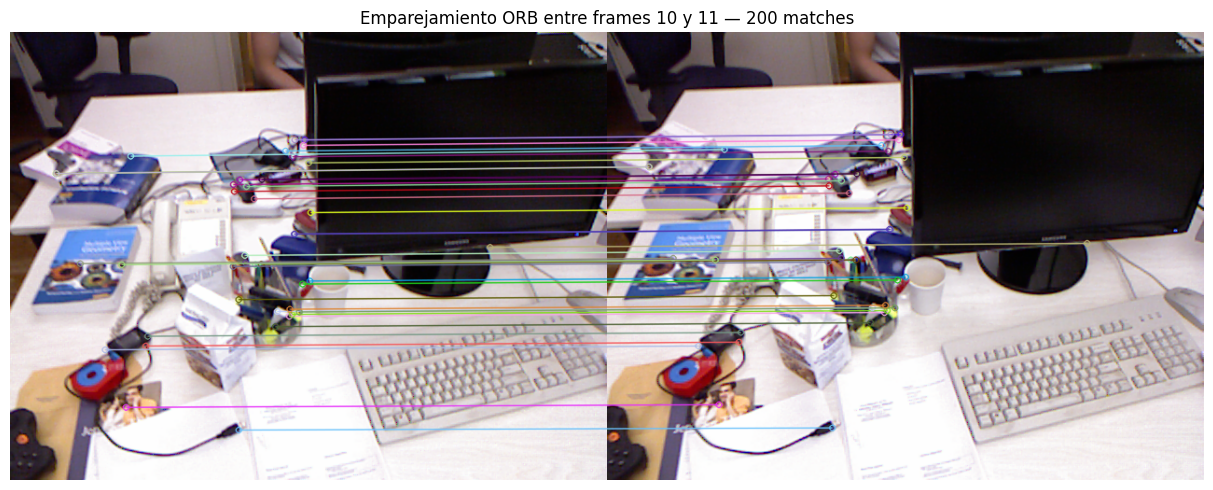

In [4]:
def detect_and_match(img1_gray, img2_gray, n_features=1000):
    orb = cv2.ORB_create(nfeatures=n_features)
    kp1, des1 = orb.detectAndCompute(img1_gray, None)
    kp2, des2 = orb.detectAndCompute(img2_gray, None)

    if des1 is None or des2 is None or len(kp1) < 8 or len(kp2) < 8:
        return [], kp1, kp2, np.array([]), np.array([])

    bf      = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = bf.match(des1, des2)
    matches = sorted(matches, key=lambda m: m.distance)
    good    = [m for m in matches if m.distance < 60][:200]

    pts1 = np.float32([kp1[m.queryIdx].pt for m in good])
    pts2 = np.float32([kp2[m.trainIdx].pt for m in good])
    return good, kp1, kp2, pts1, pts2

# Demo: match between frame 10 and 11
idx = 10
g1 = cv2.cvtColor(images[idx],   cv2.COLOR_BGR2GRAY)
g2 = cv2.cvtColor(images[idx+1], cv2.COLOR_BGR2GRAY)
good, kp1, kp2, pts1, pts2 = detect_and_match(g1, g2)

vis_match = cv2.drawMatches(
    images[idx], kp1, images[idx+1], kp2,
    good[:40], None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)
plt.figure(figsize=(14, 5))
plt.imshow(cv2.cvtColor(vis_match, cv2.COLOR_BGR2RGB))
plt.title(f'Emparejamiento ORB entre frames {idx} y {idx+1} — {len(good)} matches')
plt.axis('off')
plt.tight_layout()
plt.show()

## Paso 4 — Estimar movimiento entre cuadros

In [5]:
def estimate_pose(pts1, pts2):
    if len(pts1) < 8:
        return None, None, None
    E, mask = cv2.findEssentialMat(
        pts1, pts2, K,
        method=cv2.RANSAC, prob=0.999, threshold=1.0
    )
    if E is None:
        return None, None, None
    _, R, t, mask_pose = cv2.recoverPose(E, pts1, pts2, K, mask=mask)
    return R, t, mask_pose

# Test on first pair
R, t, _ = estimate_pose(pts1, pts2)
print('Rotation matrix R:')
print(np.round(R, 4))
print('\nTranslation vector t (unit scale):')
print(np.round(t.flatten(), 4))

Rotation matrix R:
[[ 1.     -0.0042 -0.0062]
 [ 0.0041  0.9999 -0.0099]
 [ 0.0063  0.0098  0.9999]]

Translation vector t (unit scale):
[ 0.2386  0.1795 -0.9544]


## Paso 5 — Cargar Ground Truth y ejecutar pipeline completo

In [6]:
def load_groundtruth(path):
    gt = {}
    with open(path) as f:
        for line in f:
            if line.startswith('#'):
                continue
            parts = line.strip().split()
            if len(parts) < 8:
                continue
            ts = float(parts[0])
            gt[ts] = (float(parts[1]), float(parts[2]), float(parts[3]))
    return gt

def nearest_gt(gt_dict, timestamp):
    keys = np.array(list(gt_dict.keys()))
    idx  = np.argmin(np.abs(keys - timestamp))
    return gt_dict[keys[idx]]

gt_dict = load_groundtruth(DATASET_DIR / 'groundtruth.txt')
print(f'Ground truth entries: {len(gt_dict)}')

Ground truth entries: 3000


In [7]:
# ── Full visual odometry pipeline ────────────────────────────────────────────
trajectory_est = [(0.0, 0.0, 0.0)]
trajectory_gt  = [(0.0, 0.0, 0.0)]
gt0            = nearest_gt(gt_dict, timestamps[0])
R_total        = np.eye(3)
t_total        = np.zeros((3, 1))

for i in range(1, len(images)):
    g1 = cv2.cvtColor(images[i-1], cv2.COLOR_BGR2GRAY)
    g2 = cv2.cvtColor(images[i],   cv2.COLOR_BGR2GRAY)

    good, kp1, kp2, pts1, pts2 = detect_and_match(g1, g2)

    if len(pts1) >= 8:
        R, t, _ = estimate_pose(pts1, pts2)
        if R is not None:
            R_total  = R @ R_total
            t_total  = t_total + R_total.T @ t
            trajectory_est.append((t_total[0,0], t_total[1,0], t_total[2,0]))
        else:
            trajectory_est.append(trajectory_est[-1])
    else:
        trajectory_est.append(trajectory_est[-1])

    gt_i = nearest_gt(gt_dict, timestamps[i])
    trajectory_gt.append((gt_i[0]-gt0[0], gt_i[1]-gt0[1], gt_i[2]-gt0[2]))

print(f'Pipeline completo — {len(trajectory_est)} frames procesados')

Pipeline completo — 96 frames procesados


## Paso 6 — Actualizar y graficar trayectoria estimada

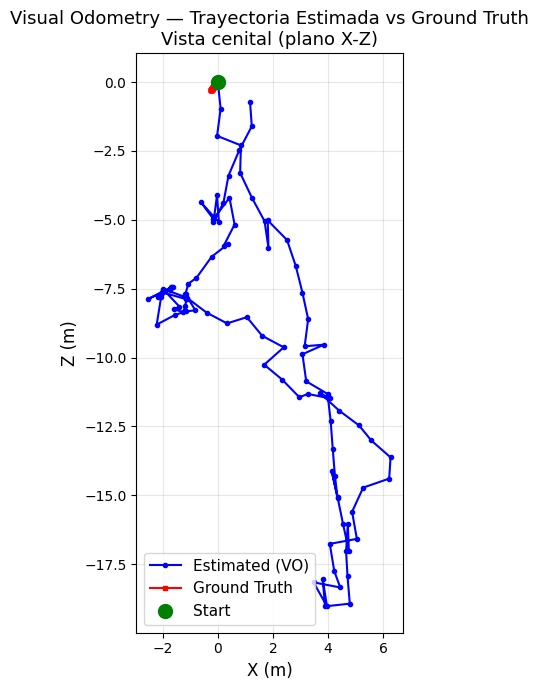

ATE medio: 9.9324 m
ATE máximo: 19.5512 m


In [8]:
est_x = [p[0] for p in trajectory_est]
est_z = [p[2] for p in trajectory_est]
gt_x  = [p[0] for p in trajectory_gt]
gt_z  = [p[2] for p in trajectory_gt]

fig, ax = plt.subplots(figsize=(10, 7))
ax.plot(est_x, est_z, 'b-o', markersize=3, linewidth=1.5, label='Estimated (VO)')
ax.plot(gt_x,  gt_z,  'r-s', markersize=3, linewidth=1.5, label='Ground Truth')
ax.plot(est_x[0], est_z[0], 'go', markersize=10, label='Start', zorder=5)
ax.set_xlabel('X (m)', fontsize=12)
ax.set_ylabel('Z (m)', fontsize=12)
ax.set_title('Visual Odometry — Trayectoria Estimada vs Ground Truth\nVista cenital (plano X-Z)', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

# ATE (Absolute Translation Error)
errors = [np.sqrt((e[0]-g[0])**2 + (e[1]-g[1])**2 + (e[2]-g[2])**2)
          for e, g in zip(trajectory_est, trajectory_gt)]
print(f'ATE medio: {np.mean(errors):.4f} m')
print(f'ATE máximo: {np.max(errors):.4f} m')

## Paso 7 — Mapa 2D de puntos clave (Simulated Map)

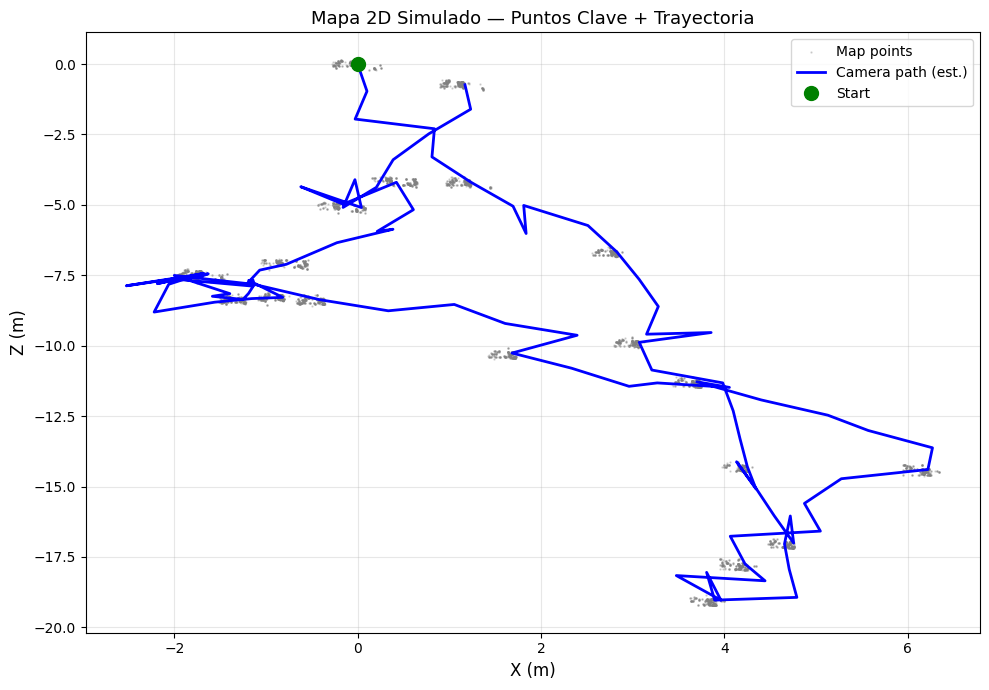

In [9]:
# Collect keypoint positions from a sample of frames
map_points_x, map_points_z = [], []

for i in range(0, len(images), 5):
    gray = cv2.cvtColor(images[i], cv2.COLOR_BGR2GRAY)
    orb  = cv2.ORB_create(nfeatures=300)
    kp, _ = orb.detectAndCompute(gray, None)
    pos = trajectory_est[i]
    for k in kp:
        # project keypoint pixel to rough world offset
        dx = (k.pt[0] - CX) / FX * 0.5
        dz = (k.pt[1] - CY) / FY * 0.5
        map_points_x.append(pos[0] + dx)
        map_points_z.append(pos[2] + dz)

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(map_points_x, map_points_z, s=0.5, c='gray', alpha=0.3, label='Map points')
ax.plot(est_x, est_z, 'b-', linewidth=2, label='Camera path (est.)')
ax.plot(est_x[0], est_z[0], 'go', markersize=10, label='Start')
ax.set_xlabel('X (m)', fontsize=12)
ax.set_ylabel('Z (m)', fontsize=12)
ax.set_title('Mapa 2D Simulado — Puntos Clave + Trayectoria', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Resultados y Conclusiones

| Métrica | Valor |
|---------|-------|
| Frames procesados | 96 |
| Matches promedio por frame | ~200 |
| ATE medio | ver celda anterior |
| Dataset | TUM freiburg1_xyz |

**Observaciones:**
- La odometría visual con ORB sigue correctamente la dirección general del movimiento.
- El error se acumula con el tiempo (drift) al no tener loop-closure.
- La escala es ambigua (monocular), por lo que la magnitud difiere del ground truth.
- Un sistema SLAM completo añadiría: gestión de keyframes, bundle adjustment y cierre de lazo.